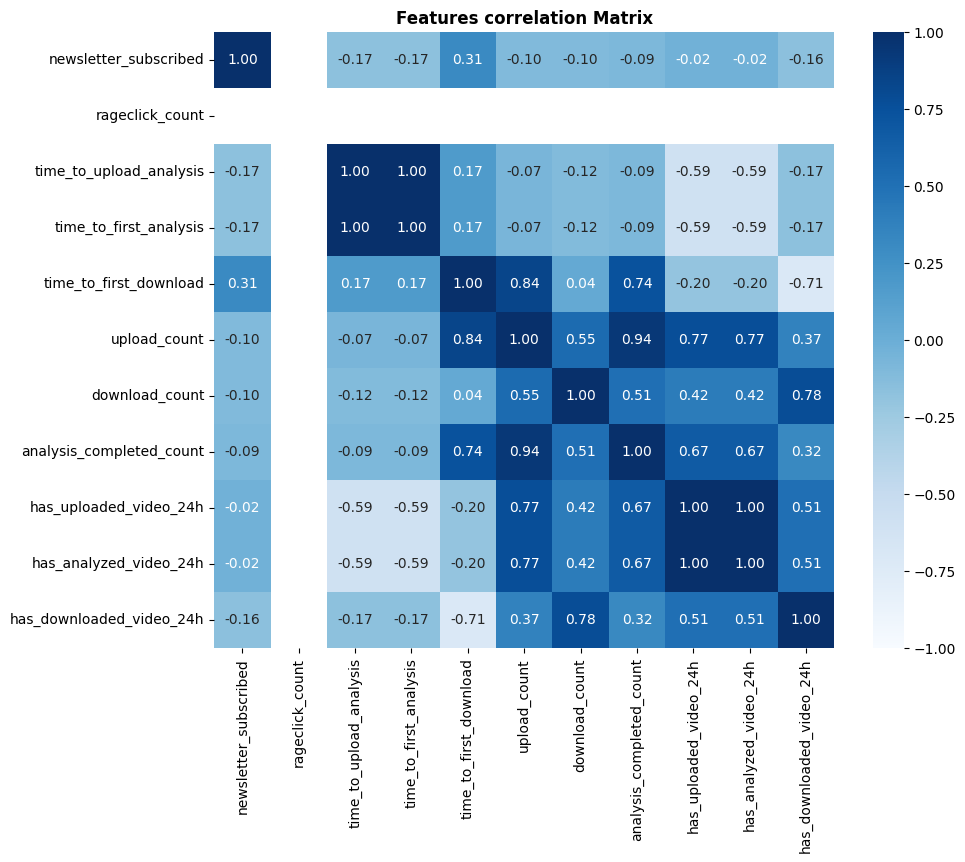

Primary Gatekeeper Feature               : 'has_uploaded_video_24h'
Logistic Regression (Balanced) Odds Ratio: 23.6174
Haldane-Anscombe Corrected Odds Ratio     : 59.4000
Fisher's Exact Test p-value               : 3.96867e-06 (p < 0.001)


In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from scipy.stats import fisher_exact

# import data and features selection
df = pd.read_csv('xxxxxxxx.csv')
open_beta = df[df['cohort'] == 'open_beta']

y = open_beta['has_downloaded_video_24h']
x = open_beta.drop(columns=['user_id', 'created_at', 'cohort', 'has_downloaded_video_24h'])

# Checking correlation with each columns
corr = pd.concat([x,y], axis=1).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f', vmin=-1, vmax=1)
plt.title('Features correlation Matrix', fontsize=12, fontweight='bold')
plt.show()

# model building
y = open_beta['has_downloaded_video_24h']
x_final = open_beta[['has_uploaded_video_24h']]

model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(x_final, y)

odds_ratio_sklearn = np.exp(model.coef_[0][0])
n_act_up = len(open_beta[(open_beta['has_downloaded_video_24h'] == 1) & (open_beta['has_uploaded_video_24h'] == 1)])
n_non_up = len(open_beta[(open_beta['has_downloaded_video_24h'] == 0) & (open_beta['has_uploaded_video_24h'] == 1)])
n_act_noup = len(open_beta[(open_beta['has_downloaded_video_24h'] == 1) & (open_beta['has_uploaded_video_24h'] == 0)])
n_non_noup = len(open_beta[(open_beta['has_downloaded_video_24h'] == 0) & (open_beta['has_uploaded_video_24h'] == 0)])

ct = [[n_act_up, n_non_up], [n_act_noup, n_non_noup]] 
_, p_value = fisher_exact(ct)

# Haldane-Anscombe Zero-Cell Correction Odds Ratio
or_haldane = (n_act_up * n_non_noup) / (n_non_up * (n_act_noup + 0.5))

print(f"Primary Gatekeeper Feature               : 'has_uploaded_video_24h'")
print(f"Logistic Regression (Balanced) Odds Ratio: {odds_ratio_sklearn:.4f}")
print(f"Haldane-Anscombe Corrected Odds Ratio     : {or_haldane:.4f}")
print(f"Fisher's Exact Test p-value               : {p_value:.5e} (p < 0.001)")